# Assignment 1 - Part 2: Software Effort Estimation

This notebook implements a reproducible workflow to:
- Use two public software effort datasets (`NASA93` and `China`) when both are available
- Audit the raw data before modeling to catch missingness, skewness, outliers, suspicious columns, and high correlations
- Develop and compare multiple estimation models plus explicit dummy baselines
- Apply rigorous validation with nested repeated cross-validation
- Evaluate with MAE, RMSE, MdAE, MASE, and MdASE
- Analyze performance and stability across datasets and outer folds without mixing datasets in the plots


## 1. Setup

Run this notebook from the project folder `assignment1_part2_effort_estimation/`.
It will download raw data snapshots into `data/raw/` and create cleaned CSV files in `data/processed/`.

In [17]:
from __future__ import annotations

import io
import json
import warnings
from pathlib import Path
from typing import Dict, Iterable, Tuple
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [18]:
# Reproducibility and runtime profile
RANDOM_STATE = 42
EPSILON = 1e-8
EDA_CORR_THRESHOLD = 0.85
MODEL_ORDER = ["ElasticNet", "RandomForest", "GradientBoosting", "DummyMean", "DummyMedian"]

RUN_PROFILE = "fast"  # options: "fast", "balanced", "full"

PROFILE_SETTINGS = {
    "fast": {
        "outer_splits": 3,
        "outer_repeats": 2,
        "inner_splits": 2,
        "model_param_grids": {
            "ElasticNet": {
                "model__alpha": [0.1, 1.0],
                "model__l1_ratio": [0.5],
            },
            "RandomForest": {
                "model__n_estimators": [150],
                "model__max_depth": [None, 10],
                "model__min_samples_leaf": [1, 3],
                "model__max_features": ["sqrt"],
            },
            "GradientBoosting": {
                "model__n_estimators": [150],
                "model__learning_rate": [0.1],
                "model__max_depth": [2],
                "model__subsample": [1.0],
            },
        },
    },
    "balanced": {
        "outer_splits": 5,
        "outer_repeats": 3,
        "inner_splits": 3,
        "model_param_grids": {
            "ElasticNet": {
                "model__alpha": [0.01, 0.1, 1.0],
                "model__l1_ratio": [0.2, 0.5, 0.8],
            },
            "RandomForest": {
                "model__n_estimators": [200, 400],
                "model__max_depth": [None, 12],
                "model__min_samples_leaf": [1, 3],
                "model__max_features": ["sqrt"],
            },
            "GradientBoosting": {
                "model__n_estimators": [200, 300],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [2, 3],
                "model__subsample": [0.8, 1.0],
            },
        },
    },
    "full": {
        "outer_splits": 5,
        "outer_repeats": 10,
        "inner_splits": 3,
        "model_param_grids": {
            "ElasticNet": {
                "model__alpha": [0.001, 0.01, 0.1, 1.0],
                "model__l1_ratio": [0.1, 0.5, 0.9],
            },
            "RandomForest": {
                "model__n_estimators": [300, 600],
                "model__max_depth": [None, 8, 16],
                "model__min_samples_leaf": [1, 3, 5],
                "model__max_features": ["sqrt", 0.6],
            },
            "GradientBoosting": {
                "model__n_estimators": [200, 400],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [2, 3, 4],
                "model__subsample": [0.7, 1.0],
            },
        },
    },
}

if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError(f"Unknown RUN_PROFILE '{RUN_PROFILE}'. Use one of: {list(PROFILE_SETTINGS)}")

ACTIVE_PROFILE = PROFILE_SETTINGS[RUN_PROFILE]
OUTER_SPLITS = ACTIVE_PROFILE["outer_splits"]
OUTER_REPEATS = ACTIVE_PROFILE["outer_repeats"]
INNER_SPLITS = ACTIVE_PROFILE["inner_splits"]
MODEL_PARAM_GRIDS = ACTIVE_PROFILE["model_param_grids"]

MIN_DATASETS = 2
MAX_DATASETS = 2

BASE_DIR = Path.cwd()
DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "figures"

DATASET_CANDIDATES = [
    {
        "name": "NASA93",
        "url": "https://zenodo.org/records/268419/files/nasa93.arff?download=1",
        "raw_name": "nasa93.arff",
        "format": "arff",
        "target": "act_effort",
        "drop": ["recordnumber"],
        "drop_reasons": {
            "recordnumber": "Unique project identifier without predictive value.",
        },
    },
    {
        "name": "China",
        "url": "https://zenodo.org/records/268446/files/china.arff?download=1",
        "raw_name": "china.arff",
        "format": "arff",
        "target": "Effort",
        "drop": ["ID", "N_effort", "PDR_AFP", "PDR_UFP", "NPDR_AFP", "NPDU_UFP"],
        "drop_reasons": {
            "ID": "Identifier without predictive value.",
            "N_effort": "Alternative effort target not available at prediction time.",
            "PDR_AFP": "Derived from Effort / AFP and leaks the target.",
            "PDR_UFP": "Derived from Effort / UFP and leaks the target.",
            "NPDR_AFP": "Derived from N_effort / AFP and leaks an alternative target.",
            "NPDU_UFP": "Derived from N_effort / UFP and leaks an alternative target.",
        },
    },
    {
        "name": "COC81",
        "url": "https://zenodo.org/records/268424/files/coc81-dem.arff?download=1",
        "raw_name": "coc81-dem.arff",
        "format": "arff",
        "target": "effort",
        "drop": ["id", "defects"],
        "drop_reasons": {
            "id": "Identifier without predictive value.",
            "defects": "Post-delivery outcome excluded from effort prediction.",
        },
    },
]

for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Run profile: {RUN_PROFILE} | outer={OUTER_SPLITS}x{OUTER_REPEATS}, inner={INNER_SPLITS}")


Run profile: fast | outer=3x2, inner=2


## 2. Data Acquisition and Loading

The helpers below snapshot candidate datasets and load them with a robust fallback strategy.
They try `NASA93`, then `China`, then `COC81`, skipping failures until at least two datasets are loaded.
When `NASA93` and `China` load successfully, they are the datasets used throughout the analysis; `COC81` remains a technical fallback only.
Compatibility note: PROMISE ARFF variants are normalized for non-standard headers and whitespace-delimited rows.


In [19]:
RATING_ORDER = ["vl", "l", "n", "h", "vh", "xh"]
RATING_SET = set(RATING_ORDER)


def download_dataset(url: str, out_path: Path) -> Path:
    """Download a file only if it is not present locally."""
    if not out_path.exists():
        print(f"Downloading {out_path.name}...")
        urlretrieve(url, out_path)
    else:
        print(f"Using cached file: {out_path.name}")
    return out_path


def _sanitize_arff_text(raw_text: str) -> str:
    """
    Normalize non-standard PROMISE headers such as:
    @class months numeric  ->  @attribute months numeric
    """
    cleaned = []
    for line in raw_text.splitlines():
        stripped = line.strip()
        if stripped.lower().startswith("@class "):
            leading_ws = line[: len(line) - len(line.lstrip())]
            cleaned.append(f"{leading_ws}@attribute {stripped[7:]}")
        else:
            cleaned.append(line)
    return "\n".join(cleaned) + "\n"


def _split_arff_sections(arff_text: str) -> tuple[list[str], list[tuple[int, str]]]:
    """Return header lines and (line_no, data_line) for non-empty data rows."""
    lines = arff_text.splitlines()
    header_lines = []
    data_lines: list[tuple[int, str]] = []
    in_data = False

    for i, line in enumerate(lines, start=1):
        stripped = line.strip()
        if not in_data:
            header_lines.append(line)
            if stripped.lower() == "@data":
                in_data = True
            continue

        if not stripped or stripped.startswith("%"):
            continue
        data_lines.append((i, stripped))

    return header_lines, data_lines


def _detect_data_delimiter(data_lines: list[tuple[int, str]]) -> str:
    if not data_lines:
        return "comma"
    return "comma" if "," in data_lines[0][1] else "whitespace"


def _parse_attribute_definition(line: str) -> dict:
    """Parse one ARFF @attribute definition."""
    raw = line.strip()[len("@attribute "):].strip()
    parts = raw.split(None, 1)
    if len(parts) < 2:
        raise ValueError(f"Malformed @attribute line: {line}")

    name = parts[0].strip("'\"")
    type_spec = parts[1].strip()
    lower_type = type_spec.lower()

    if type_spec.startswith("{") and type_spec.endswith("}"):
        kind = "nominal"
        values = [v.strip() for v in type_spec[1:-1].split(",")]
    elif lower_type in {"numeric", "real", "integer"}:
        kind = "numeric"
        values = None
    else:
        kind = "string"
        values = None

    return {"name": name, "type_spec": type_spec, "kind": kind, "values": values}


def _extract_attributes(header_lines: list[str]) -> list[dict]:
    attrs = []
    for line in header_lines:
        if line.strip().lower().startswith("@attribute "):
            attrs.append(_parse_attribute_definition(line))
    return attrs


def _tokenize_data_row(raw_row: str, delimiter: str) -> list[str]:
    if delimiter == "comma":
        return [token.strip() for token in raw_row.split(",")]
    return raw_row.split()


def load_arff(path: Path) -> pd.DataFrame:
    """Robust ARFF loader supporting comma and whitespace data rows."""
    raw_text = path.read_text(encoding="utf-8", errors="ignore")
    raw_lower = raw_text.lower()
    if "@relation" not in raw_lower or "@data" not in raw_lower:
        raise ValueError(f"File does not look like ARFF: {path}")

    sanitized_text = _sanitize_arff_text(raw_text)
    header_lines, data_lines = _split_arff_sections(sanitized_text)
    attributes = _extract_attributes(header_lines)
    if not attributes:
        raise ValueError(f"No @attribute definitions found in {path}")

    delimiter = _detect_data_delimiter(data_lines)
    expected_fields = len(attributes)

    rows = []
    for line_no, raw_row in data_lines:
        tokens = _tokenize_data_row(raw_row, delimiter)
        if len(tokens) != expected_fields:
            raise ValueError(
                f"ARFF row width mismatch at line {line_no}: "
                f"expected {expected_fields}, got {len(tokens)}. Row: {raw_row}"
            )
        rows.append(tokens)

    df = pd.DataFrame(rows, columns=[attr["name"] for attr in attributes])

    # Normalize missing markers and cast numeric columns.
    df = df.replace("?", np.nan)
    for attr in attributes:
        if attr["kind"] == "numeric":
            df[attr["name"]] = pd.to_numeric(df[attr["name"]], errors="coerce")

    return df


def snapshot_and_load(dataset_name: str, cfg: dict) -> pd.DataFrame:
    raw_path = DATA_RAW_DIR / cfg["raw_name"]
    download_dataset(cfg["url"], raw_path)

    dataset_format = cfg.get("format", "arff").lower()
    if dataset_format != "arff":
        raise ValueError(f"Unsupported dataset format: {dataset_format}")

    df = load_arff(raw_path)
    out_csv = DATA_PROCESSED_DIR / f"{dataset_name.lower()}_clean.csv"
    df.to_csv(out_csv, index=False)
    return df


def _validate_dataset_for_modeling(df: pd.DataFrame, cfg: dict) -> None:
    target = cfg["target"]
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")
    if len(df) < 10:
        raise ValueError("Dataset has too few rows for cross-validation")


def load_available_datasets(
    candidates: list[dict],
    min_required: int = 2,
    max_selected: int = 2,
) -> tuple[dict[str, dict], pd.DataFrame]:
    """
    Attempt candidate datasets in order and keep successful loads.
    Returns selected datasets map and a load report dataframe.
    """
    selected: dict[str, dict] = {}
    report_rows = []

    for cfg in candidates:
        name = cfg["name"]
        try:
            df = snapshot_and_load(name, cfg)
            _validate_dataset_for_modeling(df, cfg)

            selected[name] = {"cfg": cfg, "df": df}
            report_rows.append(
                {
                    "dataset": name,
                    "status": "loaded",
                    "rows": int(df.shape[0]),
                    "columns": int(df.shape[1]),
                    "error": "",
                }
            )
        except Exception as exc:
            report_rows.append(
                {
                    "dataset": name,
                    "status": "failed",
                    "rows": 0,
                    "columns": 0,
                    "error": str(exc),
                }
            )

        if len(selected) >= max_selected:
            break

    report_df = pd.DataFrame(report_rows)
    report_df.to_csv(BASE_DIR / "dataset_load_report.csv", index=False)

    if len(selected) < min_required:
        loaded = list(selected.keys())
        raise RuntimeError(
            f"Only {len(selected)} dataset(s) loaded ({loaded}). "
            f"At least {min_required} required. See dataset_load_report.csv for details."
        )

    return selected, report_df




def get_modeling_frame(df: pd.DataFrame, cfg: dict) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    target_col = cfg["target"]
    drop_cols = [c for c in cfg.get("drop", []) if c in df.columns]
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].astype(float)
    return X, y, drop_cols


In [20]:
selected_datasets, dataset_load_report = load_available_datasets(
    DATASET_CANDIDATES,
    min_required=MIN_DATASETS,
    max_selected=MAX_DATASETS,
)

selected_dataset_configs = {name: payload["cfg"] for name, payload in selected_datasets.items()}
datasets_df = {name: payload["df"] for name, payload in selected_datasets.items()}

print("Dataset load report:")
display(dataset_load_report)

print("Selected datasets:", list(datasets_df.keys()))
for name, df in datasets_df.items():
    print(f"{name}: shape={df.shape}")
    display(df.head())



Using cached file: nasa93.arff
Using cached file: china.arff
Dataset load report:


,dataset,status,rows,columns,error
0,NASA93,loaded,93,24,
1,China,loaded,499,19,


Selected datasets: ['NASA93', 'China']
NASA93: shape=(93, 24)


,recordnumber,projectname,cat2,forg,center,year,mode,rely,data,cplx,...,acap,aexp,pcap,vexp,lexp,modp,tool,sced,equivphyskloc,act_effort
0,1,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,25.9,117.6
1,2,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,24.6,117.6
2,3,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,7.7,31.2
3,4,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,8.2,36.0
4,5,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,9.7,25.2


China: shape=(499, 19)


,ID,AFP,Input,Output,Enquiry,File,Interface,Added,Changed,Deleted,PDR_AFP,PDR_UFP,NPDR_AFP,NPDU_UFP,Resource,Dev.Type,Duration,N_effort,Effort
0,1,1587,774,260,340,128,0,1502,0,0,4.7,5.0,4.7,5.0,4,0,4.0,7490,7490
1,2,260,9,4,3,193,41,51,138,61,16.0,16.6,16.0,16.6,2,0,17.0,4150,4150
2,3,152,25,33,28,42,35,163,0,0,4.4,4.1,4.4,4.1,1,0,9.0,668,668
3,4,252,151,28,8,39,0,69,153,4,12.8,14.3,15.5,17.3,1,0,4.0,3901,3238
4,5,292,93,0,194,20,0,0,307,0,10.3,9.8,12.4,11.7,1,0,13.0,3607,2994


## 3. Exploratory Data Audit

The audit below checks missingness, target skewness, outliers, excluded columns, and strong correlations among numeric predictors **after** leakage-prone variables are removed from the modeling frame.


=== NASA93 audit ===
Rows=93, columns=24, predictors after exclusions=22
Numeric predictors=2, categorical predictors=20
Target skewness=4.257 | IQR outliers=10
Excluded columns before modeling:


,column,reason
0,recordnumber,Unique project identifier without predictive v...


Missing values: none detected in the current snapshot.
No numeric predictor pairs above |corr| >= 0.85 after exclusions.


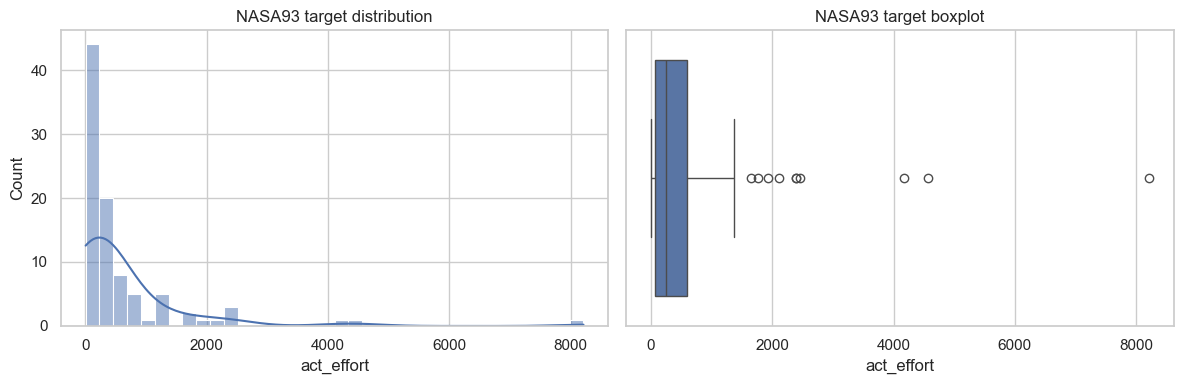

=== China audit ===
Rows=499, columns=19, predictors after exclusions=12
Numeric predictors=12, categorical predictors=0
Target skewness=3.929 | IQR outliers=54
Excluded columns before modeling:


,column,reason
0,ID,Identifier without predictive value.
1,N_effort,Alternative effort target not available at pre...
2,PDR_AFP,Derived from Effort / AFP and leaks the target.
3,PDR_UFP,Derived from Effort / UFP and leaks the target.
4,NPDR_AFP,Derived from N_effort / AFP and leaks an alter...
5,NPDU_UFP,Derived from N_effort / UFP and leaks an alter...


Missing values: none detected in the current snapshot.
Top numeric predictor pairs above |corr| >= 0.85:


,feature_a,feature_b,abs_corr
0,AFP,Added,0.933307
1,AFP,Input,0.929968
2,AFP,File,0.914711
3,Input,Added,0.902650
4,File,Added,0.879229


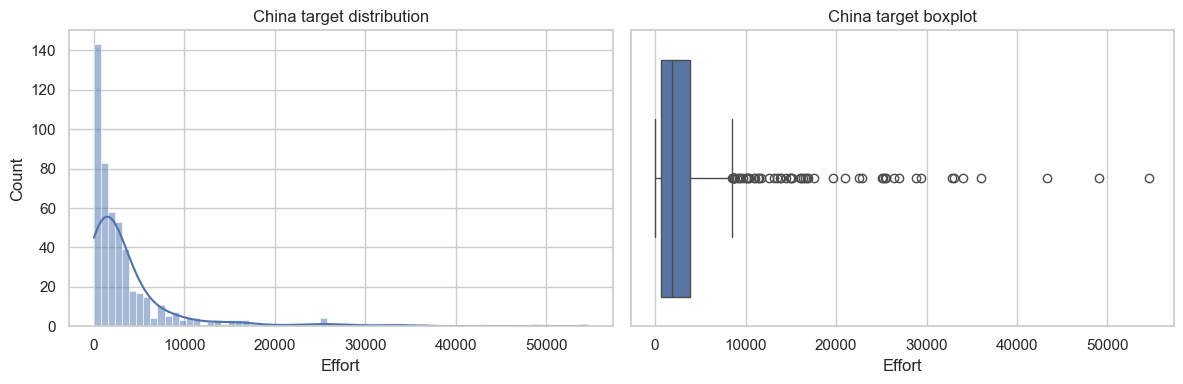

Combined EDA summary:


,dataset,rows,columns,predictors_after_drop,numeric_predictors,categorical_predictors,missing_cells,target_mean,target_median,target_skew,target_iqr,iqr_outliers
0,NASA93,93,24,22,2,20,0,624.4118,252.0,4.2570,530.0,10
1,China,499,19,12,12,0,0,3921.0481,1829.0,3.9287,3123.0,54


In [21]:
def summarize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    missing_df = (
        df.isna()
        .sum()
        .rename("missing_count")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    missing_df["missing_pct"] = missing_df["missing_count"] / len(df)
    missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
        ["missing_count", "column"], ascending=[False, True]
    )
    return missing_df.reset_index(drop=True)


def find_high_correlation_pairs(X: pd.DataFrame, threshold: float = EDA_CORR_THRESHOLD) -> pd.DataFrame:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 2:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

    corr = X[numeric_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = []
    for col in upper.columns:
        strong_pairs = upper.index[upper[col] >= threshold].tolist()
        for row_name in strong_pairs:
            pairs.append(
                {
                    "feature_a": row_name,
                    "feature_b": col,
                    "abs_corr": float(upper.loc[row_name, col]),
                }
            )

    if not pairs:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

    return pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)


eda_rows = []

for dataset_name, cfg in selected_dataset_configs.items():
    df = datasets_df[dataset_name].copy()
    X, y, drop_cols = get_modeling_frame(df, cfg)

    predictor_numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    predictor_categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    missing_df = summarize_missing_values(df)
    corr_pairs_df = find_high_correlation_pairs(X)

    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr_value = q3 - q1
    lower_bound = q1 - 1.5 * iqr_value
    upper_bound = q3 + 1.5 * iqr_value
    outlier_count = int(((y < lower_bound) | (y > upper_bound)).sum())

    eda_rows.append(
        {
            "dataset": dataset_name,
            "rows": int(len(df)),
            "columns": int(df.shape[1]),
            "predictors_after_drop": int(X.shape[1]),
            "numeric_predictors": int(len(predictor_numeric_cols)),
            "categorical_predictors": int(len(predictor_categorical_cols)),
            "missing_cells": int(df.isna().sum().sum()),
            "target_mean": float(y.mean()),
            "target_median": float(y.median()),
            "target_skew": float(y.skew()),
            "target_iqr": float(iqr_value),
            "iqr_outliers": outlier_count,
        }
    )

    print(f"=== {dataset_name} audit ===")
    print(f"Rows={len(df)}, columns={df.shape[1]}, predictors after exclusions={X.shape[1]}")
    print(f"Numeric predictors={len(predictor_numeric_cols)}, categorical predictors={len(predictor_categorical_cols)}")
    print(f"Target skewness={y.skew():.3f} | IQR outliers={outlier_count}")

    if drop_cols:
        exclusion_df = pd.DataFrame(
            {
                "column": drop_cols,
                "reason": [cfg.get("drop_reasons", {}).get(col, "Excluded before modeling") for col in drop_cols],
            }
        )
        print("Excluded columns before modeling:")
        display(exclusion_df)

    if missing_df.empty:
        print("Missing values: none detected in the current snapshot.")
    else:
        print("Missing values by column:")
        display(missing_df)

    if corr_pairs_df.empty:
        print(f"No numeric predictor pairs above |corr| >= {EDA_CORR_THRESHOLD:.2f} after exclusions.")
    else:
        print(f"Top numeric predictor pairs above |corr| >= {EDA_CORR_THRESHOLD:.2f}:")
        display(corr_pairs_df.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(y, kde=True, ax=axes[0])
    axes[0].set_title(f"{dataset_name} target distribution")
    axes[0].set_xlabel(cfg["target"])

    sns.boxplot(x=y, ax=axes[1])
    axes[1].set_title(f"{dataset_name} target boxplot")
    axes[1].set_xlabel(cfg["target"])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"eda_target_{dataset_name.lower()}.png", dpi=150)
    plt.show()

eda_summary_df = pd.DataFrame(eda_rows).round(4)
print("Combined EDA summary:")
display(eda_summary_df)


## 4. Preprocessing Design

- Numerical variables: median imputation
- Ordered categorical ratings (e.g., `vl < l < n < h < vh < xh`): ordinal encoding
- Remaining categorical variables: one-hot encoding
- China removes leakage-prone effort derivatives before modeling (`PDR_*`, `NPDR_*`, `NPDU_*`, `N_effort`)
- Target skewness control: the main tuned models use `log1p(y)` internally via `TransformedTargetRegressor`, while scoring and final metrics stay on the original effort scale


In [22]:
def split_feature_types(X: pd.DataFrame) -> Tuple[list, list, list]:
    """
    Return numeric, ordinal-categorical, and nominal-categorical columns.
    A categorical column is treated as ordinal when all observed values belong to
    the standard COCOMO rating scale.
    """
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    ordinal_cols = []
    nominal_cols = []

    for col in categorical_cols:
        values = set(str(v) for v in X[col].dropna().unique())
        if values and values.issubset(RATING_SET):
            ordinal_cols.append(col)
        else:
            nominal_cols.append(col)

    return numeric_cols, ordinal_cols, nominal_cols


def build_preprocessor(X: pd.DataFrame, for_linear: bool) -> ColumnTransformer:
    numeric_cols, ordinal_cols, nominal_cols = split_feature_types(X)

    transformers = []

    if numeric_cols:
        numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
        if for_linear:
            numeric_steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(steps=numeric_steps), numeric_cols))

    if ordinal_cols:
        transformers.append(
            (
                "ord",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OrdinalEncoder(
                                categories=[RATING_ORDER] * len(ordinal_cols),
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                            ),
                        ),
                    ]
                ),
                ordinal_cols,
            )
        )

    if nominal_cols:
        transformers.append(
            (
                "nom",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                nominal_cols,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder="drop")



## 5. Models and Hyperparameter Spaces

The workflow compares three tuned regressors plus two explicit baselines:
1. `ElasticNet` (regression-based requirement)
2. `RandomForestRegressor`
3. `GradientBoostingRegressor`
4. `DummyRegressor(strategy="mean")`
5. `DummyRegressor(strategy="median")`


In [23]:
def wrap_target_regressor(regressor) -> TransformedTargetRegressor:
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def prefix_param_grid(param_grid: dict) -> dict:
    return {f"regressor__{key}": values for key, values in param_grid.items()}


def make_model_pipelines(X: pd.DataFrame, random_state: int = 42) -> Dict[str, dict]:
    pre_linear = build_preprocessor(X, for_linear=True)
    pre_tree = build_preprocessor(X, for_linear=False)

    elastic_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_linear),
            ("model", ElasticNet(max_iter=20000, random_state=random_state)),
        ]
    )

    rf_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_tree),
            ("model", RandomForestRegressor(random_state=random_state, n_jobs=-1)),
        ]
    )

    gbr_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_tree),
            ("model", GradientBoostingRegressor(random_state=random_state)),
        ]
    )

    model_specs = {
        "ElasticNet": {
            "estimator": wrap_target_regressor(elastic_pipeline),
            "param_grid": prefix_param_grid(MODEL_PARAM_GRIDS["ElasticNet"]),
        },
        "RandomForest": {
            "estimator": wrap_target_regressor(rf_pipeline),
            "param_grid": prefix_param_grid(MODEL_PARAM_GRIDS["RandomForest"]),
        },
        "GradientBoosting": {
            "estimator": wrap_target_regressor(gbr_pipeline),
            "param_grid": prefix_param_grid(MODEL_PARAM_GRIDS["GradientBoosting"]),
        },
        "DummyMean": {
            "estimator": DummyRegressor(strategy="mean"),
            "param_grid": None,
        },
        "DummyMedian": {
            "estimator": DummyRegressor(strategy="median"),
            "param_grid": None,
        },
    }

    return model_specs


## 6. Metric Functions

`MASE` and `MdASE` are reported as a fold-wise adaptation that scales errors against a naive constant predictor based on the **training-fold median effort**. They are useful here, but this is not the canonical time-series formulation.


In [24]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_train_fold: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train_fold = np.asarray(y_train_fold, dtype=float)

    abs_errors = np.abs(y_true - y_pred)

    train_median = np.median(y_train_fold)
    naive_train_errors = np.abs(y_train_fold - train_median)

    naive_mae_scale = max(np.mean(naive_train_errors), EPSILON)
    naive_mdae_scale = max(np.median(naive_train_errors), EPSILON)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mdae = median_absolute_error(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MdAE": mdae,
        "MASE": mae / naive_mae_scale,
        "MdASE": mdae / naive_mdae_scale,
    }

## 7. Nested Repeated Cross-Validation Evaluation

- Outer loop: `RepeatedKFold(5 splits, 10 repeats)` for robust generalization estimation.
- Inner loop: `KFold(3)` inside each outer training fold for hyperparameter tuning.
- Scoring during tuning: negative MAE on the **original effort scale**; the log transform is applied internally by `TransformedTargetRegressor`.
- Baselines (`DummyMean`, `DummyMedian`) are fit only on the outer training folds, without inner tuning.


In [25]:
def _count_grid_combinations(param_grid: dict) -> int:
    combinations = 1
    for values in param_grid.values():
        combinations *= len(values)
    return combinations


def evaluate_nested_cv(
    X: pd.DataFrame,
    y: pd.Series,
    dataset_name: str,
    random_state: int = 42,
) -> pd.DataFrame:
    model_specs = make_model_pipelines(X, random_state=random_state)

    outer_cv = RepeatedKFold(
        n_splits=OUTER_SPLITS,
        n_repeats=OUTER_REPEATS,
        random_state=random_state,
    )

    total_outer_folds = OUTER_SPLITS * OUTER_REPEATS
    estimated_fits = 0
    for spec in model_specs.values():
        if spec["param_grid"]:
            estimated_fits += total_outer_folds * (_count_grid_combinations(spec["param_grid"]) * INNER_SPLITS + 1)
        else:
            estimated_fits += total_outer_folds

    print(f"[{dataset_name}] Estimated model fits: {estimated_fits}")

    rows = []

    for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        print(f"[{dataset_name}] Fold {fold_id}/{total_outer_folds}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx].astype(float)
        y_test = y.iloc[test_idx].astype(float)

        inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=random_state)

        for model_index, (model_name, spec) in enumerate(model_specs.items(), start=1):
            print(f"[{dataset_name}]   Model {model_index}/{len(model_specs)}: {model_name}")

            estimator = clone(spec["estimator"])
            param_grid = spec["param_grid"]

            if param_grid:
                gs = GridSearchCV(
                    estimator=estimator,
                    param_grid=param_grid,
                    cv=inner_cv,
                    scoring="neg_mean_absolute_error",
                    n_jobs=-1,
                    refit=True,
                )
                gs.fit(X_train, y_train)
                fitted_estimator = gs.best_estimator_
                best_params = gs.best_params_
            else:
                fitted_estimator = estimator.fit(X_train, y_train)
                best_params = {}

            y_pred = np.asarray(fitted_estimator.predict(X_test), dtype=float)
            y_pred = np.clip(y_pred, a_min=0, a_max=None)

            metrics = compute_metrics(y_test.to_numpy(), y_pred, y_train.to_numpy())

            row = {
                "dataset": dataset_name,
                "fold": fold_id,
                "model": model_name,
                "best_params": json.dumps(best_params),
            }
            row.update(metrics)
            rows.append(row)

    return pd.DataFrame(rows)


In [26]:
all_results = []

for dataset_name, cfg in selected_dataset_configs.items():
    df = datasets_df[dataset_name].copy()
    X, y, drop_cols = get_modeling_frame(df, cfg)

    print(f"Evaluating {dataset_name}: X={X.shape}, y={y.shape}")
    if drop_cols:
        print(f"Excluded before modeling: {drop_cols}")
    result_df = evaluate_nested_cv(X, y, dataset_name=dataset_name, random_state=RANDOM_STATE)
    all_results.append(result_df)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv(BASE_DIR / "results_by_fold.csv", index=False)

print("Saved fold-level metrics to results_by_fold.csv")
results_df.head()


Evaluating NASA93: X=(93, 22), y=(93,)
Excluded before modeling: ['recordnumber']
[NASA93] Estimated model fits: 114
[NASA93] Fold 1/6
[NASA93]   Model 1/5: ElasticNet
[NASA93]   Model 2/5: RandomForest
[NASA93]   Model 3/5: GradientBoosting
[NASA93]   Model 4/5: DummyMean
[NASA93]   Model 5/5: DummyMedian
[NASA93] Fold 2/6
[NASA93]   Model 1/5: ElasticNet
[NASA93]   Model 2/5: RandomForest
[NASA93]   Model 3/5: GradientBoosting
[NASA93]   Model 4/5: DummyMean
[NASA93]   Model 5/5: DummyMedian
[NASA93] Fold 3/6
[NASA93]   Model 1/5: ElasticNet
[NASA93]   Model 2/5: RandomForest
[NASA93]   Model 3/5: GradientBoosting
[NASA93]   Model 4/5: DummyMean
[NASA93]   Model 5/5: DummyMedian
[NASA93] Fold 4/6
[NASA93]   Model 1/5: ElasticNet
[NASA93]   Model 2/5: RandomForest
[NASA93]   Model 3/5: GradientBoosting
[NASA93]   Model 4/5: DummyMean
[NASA93]   Model 5/5: DummyMedian
[NASA93] Fold 5/6
[NASA93]   Model 1/5: ElasticNet
[NASA93]   Model 2/5: RandomForest
[NASA93]   Model 3/5: GradientBoo

,dataset,fold,model,best_params,MAE,RMSE,MdAE,MASE,MdASE
0,NASA93,1,ElasticNet,"{""regressor__model__alpha"": 1.0, ""regressor__m...",200.332896,287.132661,139.470944,0.292493,0.571602
1,NASA93,1,RandomForest,"{""regressor__model__max_depth"": null, ""regress...",173.322027,288.374312,52.417394,0.253056,0.214825
2,NASA93,1,GradientBoosting,"{""regressor__model__learning_rate"": 0.1, ""regr...",204.042953,433.126241,67.908306,0.297910,0.278313
3,NASA93,1,DummyMean,{},530.455307,563.072377,588.372581,0.774484,2.411363
4,NASA93,1,DummyMedian,{},236.341935,314.147241,191.000000,0.345068,0.782787


## 8. Aggregation and Stability Analysis


In [27]:
def iqr(series: pd.Series) -> float:
    return float(series.quantile(0.75) - series.quantile(0.25))

metric_cols = ["MAE", "RMSE", "MdAE", "MASE", "MdASE"]

summary_df = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .agg(["mean", "median", "std", iqr])
)
summary_df.columns = ["_".join(col).strip("_") for col in summary_df.columns]
summary_df = summary_df.rename(columns={"dataset_": "dataset", "model_": "model"})

summary_df.to_csv(BASE_DIR / "results_summary.csv", index=False)
print("Saved aggregate metrics to results_summary.csv")

summary_df

Saved aggregate metrics to results_summary.csv


,dataset,model,MAE_mean,MAE_median,MAE_std,MAE_iqr,RMSE_mean,RMSE_median,RMSE_std,RMSE_iqr,...,MdAE_std,MdAE_iqr,MASE_mean,MASE_median,MASE_std,MASE_iqr,MdASE_mean,MdASE_median,MdASE_std,MdASE_iqr
0,China,DummyMean,3695.847582,3661.272242,241.504492,241.533167,6425.171306,6363.949180,932.288398,1090.730557,...,117.839619,148.149341,1.194014,1.165923,0.136328,0.171449,2.128631,2.118804,0.067675,0.049168
1,China,DummyMedian,3111.958877,3048.445783,305.587702,490.259036,6738.009019,6667.210753,965.214271,1234.587404,...,63.329101,75.875000,1.006971,0.970667,0.150368,0.236928,0.995249,1.006608,0.049261,0.075968
2,China,ElasticNet,2967.712674,2982.133874,262.670756,301.192164,6331.695745,6162.391872,834.155365,1039.873674,...,65.270433,52.231428,0.959709,0.949549,0.131971,0.170652,0.901837,0.917947,0.048394,0.049085
3,China,GradientBoosting,2401.903729,2465.918157,265.548203,421.532806,5272.801224,5260.223012,922.708450,1660.581951,...,103.911017,169.301048,0.775752,0.756373,0.111048,0.168686,0.712481,0.700512,0.073355,0.122239
4,China,RandomForest,2332.230180,2287.868548,280.060505,443.542959,4937.142314,4886.383807,944.779094,1381.230895,...,100.785701,147.686721,0.755130,0.719047,0.127677,0.194891,0.688878,0.690632,0.068931,0.092291
5,NASA93,DummyMean,660.673378,670.923049,86.085483,67.032037,1095.783796,1045.230328,382.366819,542.362870,...,95.314272,137.371774,1.292084,1.314143,0.351758,0.431265,2.423242,2.356072,0.309330,0.307499
6,NASA93,DummyMedian,546.446237,588.153226,190.833933,239.312903,1105.363019,1109.971614,493.344383,597.604122,...,28.007356,34.150000,1.103413,1.185524,0.516384,0.739301,1.103563,1.076330,0.233455,0.292521
7,NASA93,ElasticNet,3454.101125,668.968802,4581.220930,6457.286647,17512.313689,1582.718051,25455.821572,36059.411040,...,29.992853,38.394231,6.803590,1.473162,9.156613,11.019094,0.843850,0.801078,0.334305,0.519499
8,NASA93,GradientBoosting,341.288197,339.607174,106.917100,130.687222,753.174178,732.577753,239.760106,364.059742,...,31.408700,49.104067,0.684502,0.685983,0.306857,0.407625,0.430018,0.443840,0.241435,0.377464
9,NASA93,RandomForest,363.754215,410.192206,126.303125,182.257730,837.213283,901.167881,379.267762,551.830885,...,39.815716,54.328391,0.731609,0.811077,0.337851,0.531482,0.553589,0.460166,0.307903,0.452814


In [28]:
rank_table = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .mean()
)

for metric in metric_cols:
    rank_table[f"rank_{metric}"] = rank_table.groupby("dataset")[metric].rank(method="dense", ascending=True)

rank_table = rank_table.sort_values(["dataset", "rank_MAE", "rank_RMSE"])
rank_table.to_csv(BASE_DIR / "model_ranking.csv", index=False)
rank_table

,dataset,model,MAE,RMSE,MdAE,MASE,MdASE,rank_MAE,rank_RMSE,rank_MdAE,rank_MASE,rank_MdASE
4,China,RandomForest,2332.230180,4937.142314,907.177951,0.755130,0.688878,1.0,1.0,1.0,1.0,1.0
3,China,GradientBoosting,2401.903729,5272.801224,937.920479,0.775752,0.712481,2.0,2.0,2.0,2.0,2.0
2,China,ElasticNet,2967.712674,6331.695745,1186.504939,0.959709,0.901837,3.0,3.0,3.0,3.0,3.0
1,China,DummyMedian,3111.958877,6738.009019,1309.250000,1.006971,0.995249,4.0,5.0,4.0,4.0,4.0
0,China,DummyMean,3695.847582,6425.171306,2801.225192,1.194014,2.128631,5.0,4.0,5.0,5.0,5.0
8,NASA93,GradientBoosting,341.288197,753.174178,80.371319,0.684502,0.430018,1.0,1.0,1.0,1.0,1.0
9,NASA93,RandomForest,363.754215,837.213283,105.647061,0.731609,0.553589,2.0,2.0,2.0,2.0,2.0
6,NASA93,DummyMedian,546.446237,1105.363019,223.200000,1.103413,1.103563,3.0,4.0,4.0,3.0,4.0
5,NASA93,DummyMean,660.673378,1095.783796,501.226344,1.292084,2.423242,4.0,3.0,5.0,4.0,5.0
7,NASA93,ElasticNet,3454.101125,17512.313689,163.543990,6.803590,0.843850,5.0,5.0,3.0,5.0,3.0


## 9. Visualization


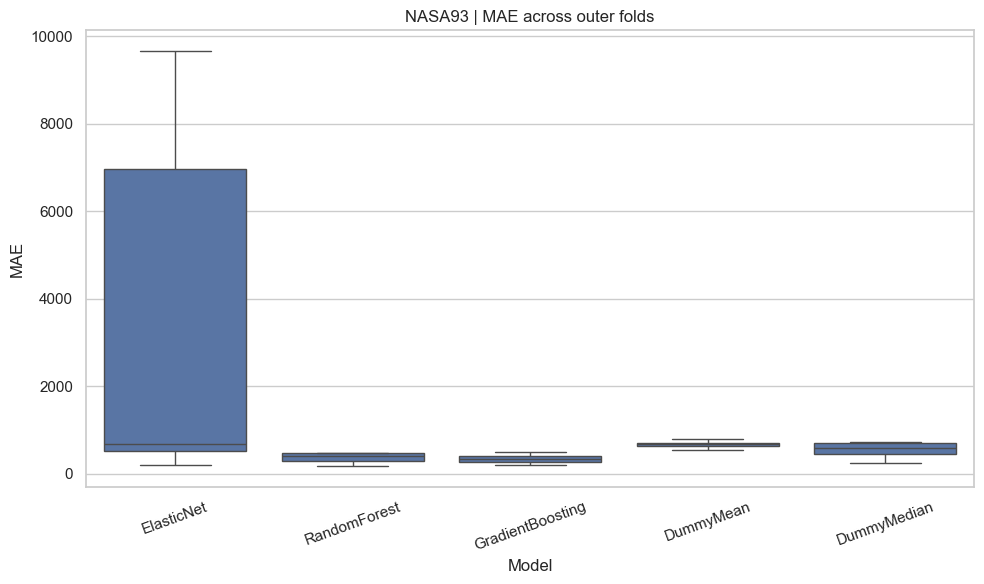

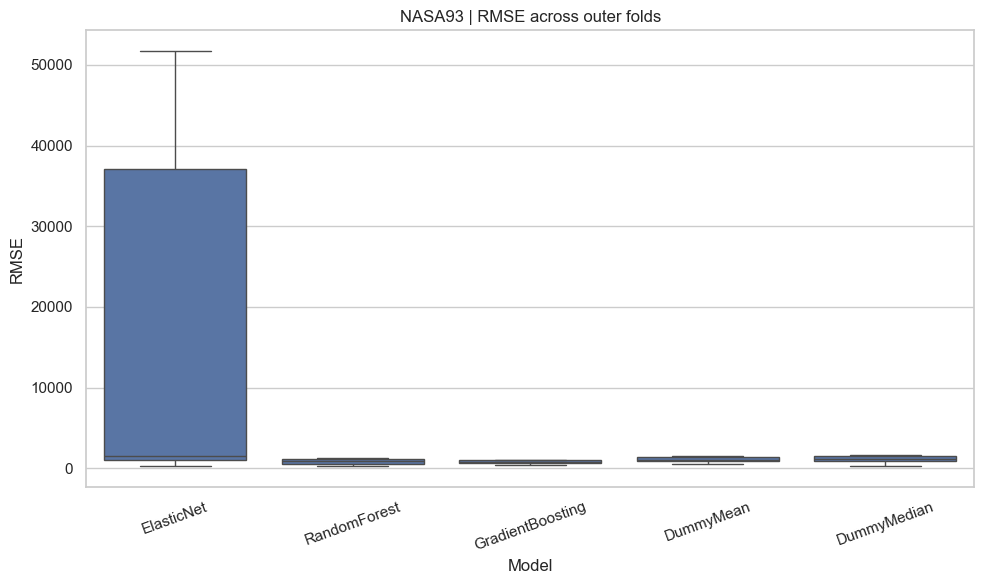

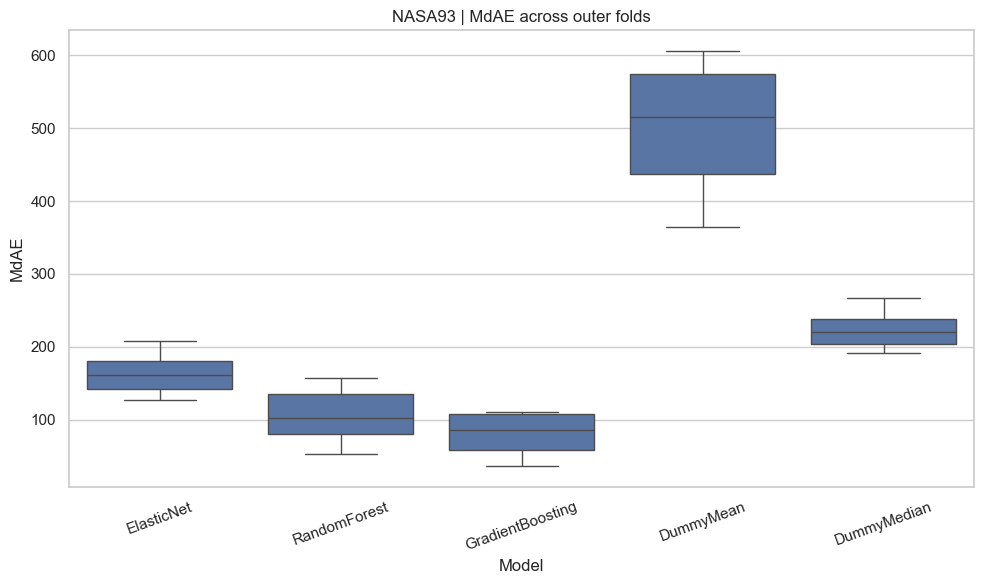

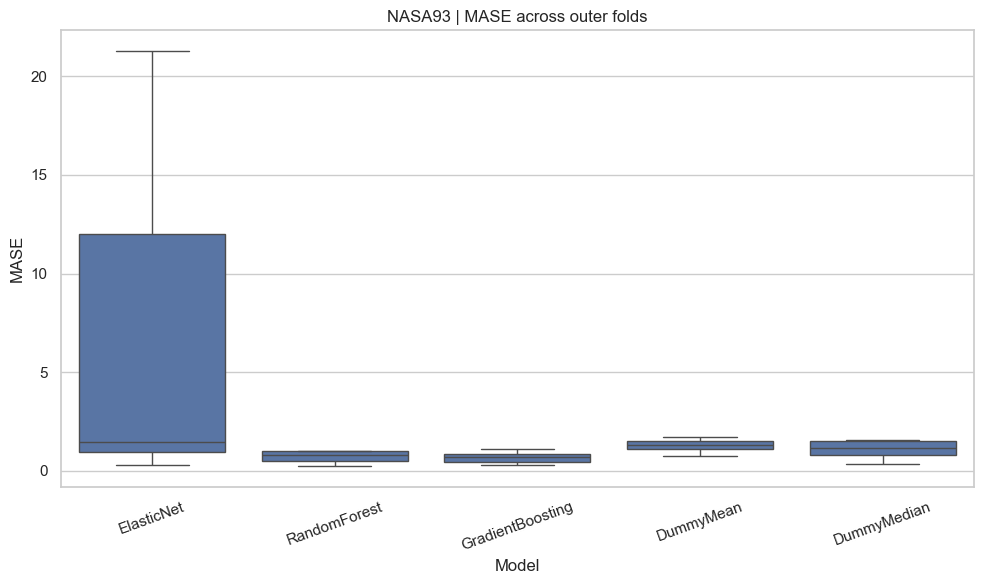

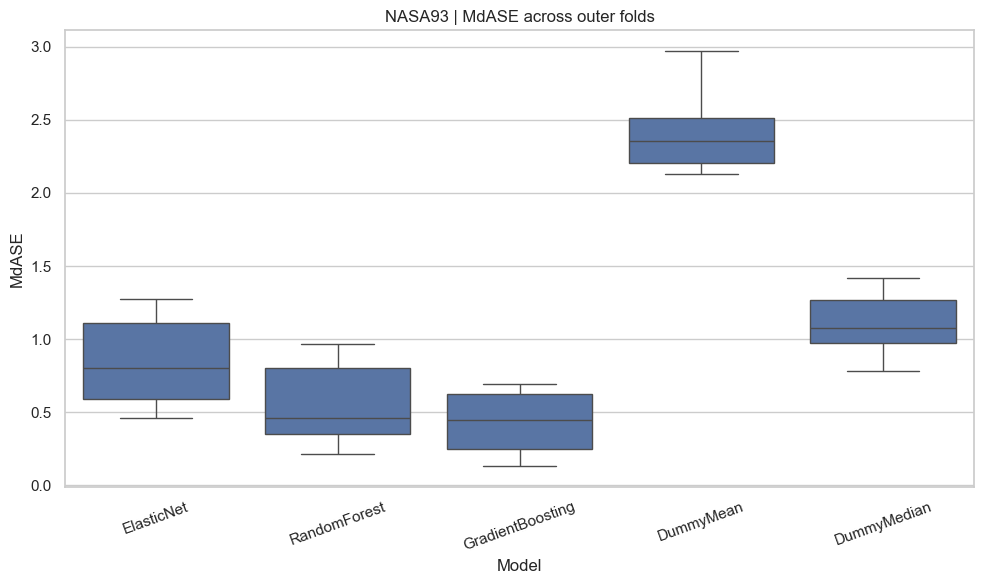

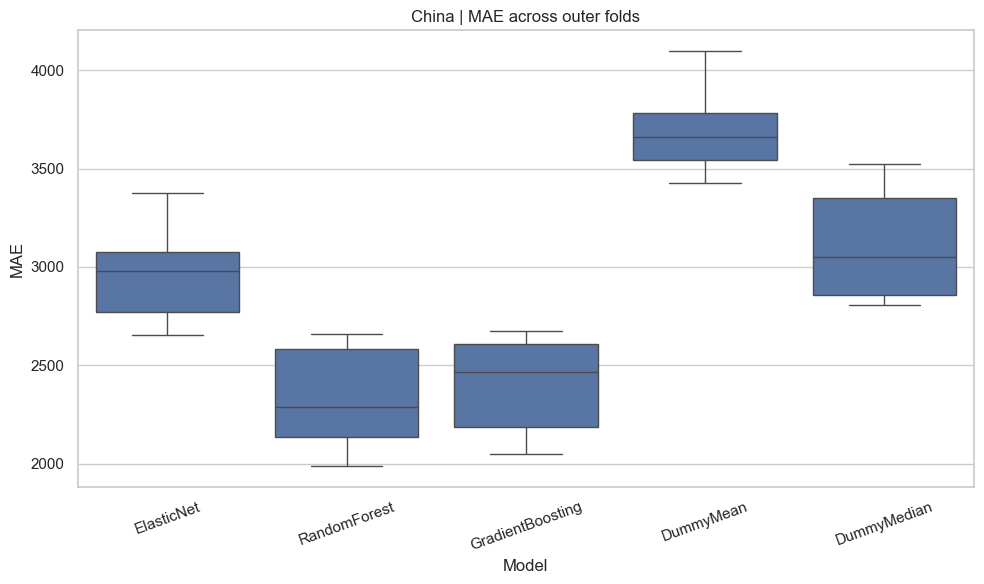

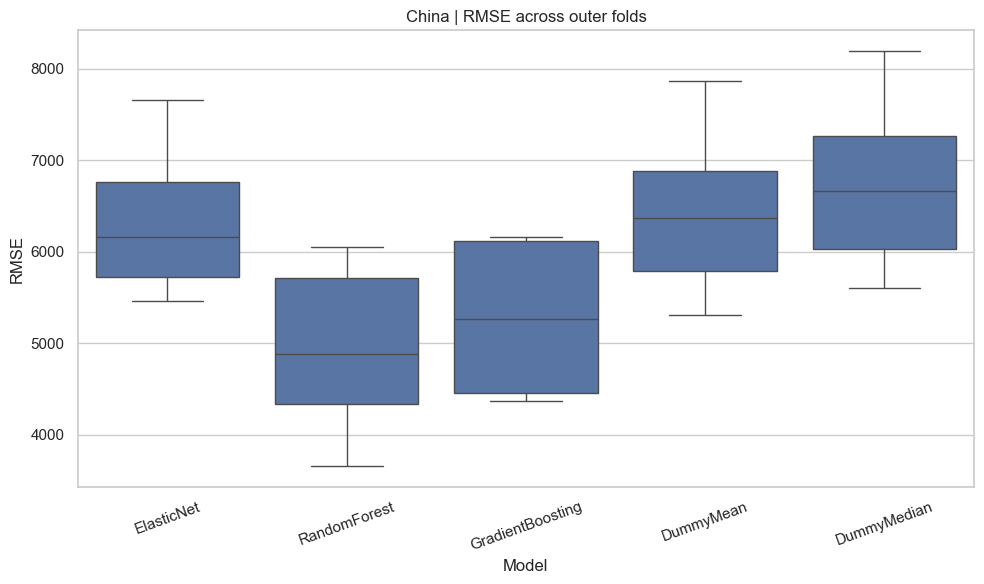

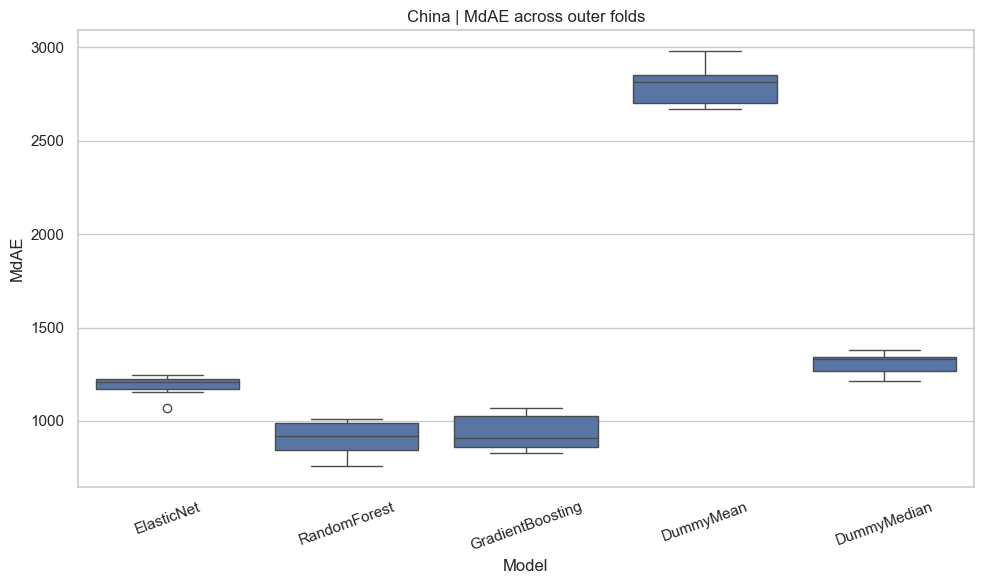

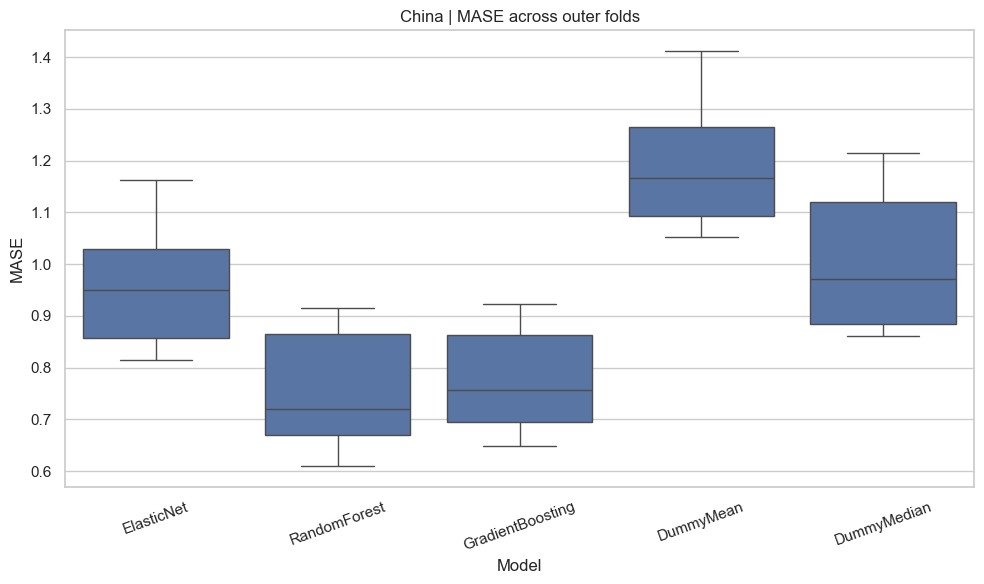

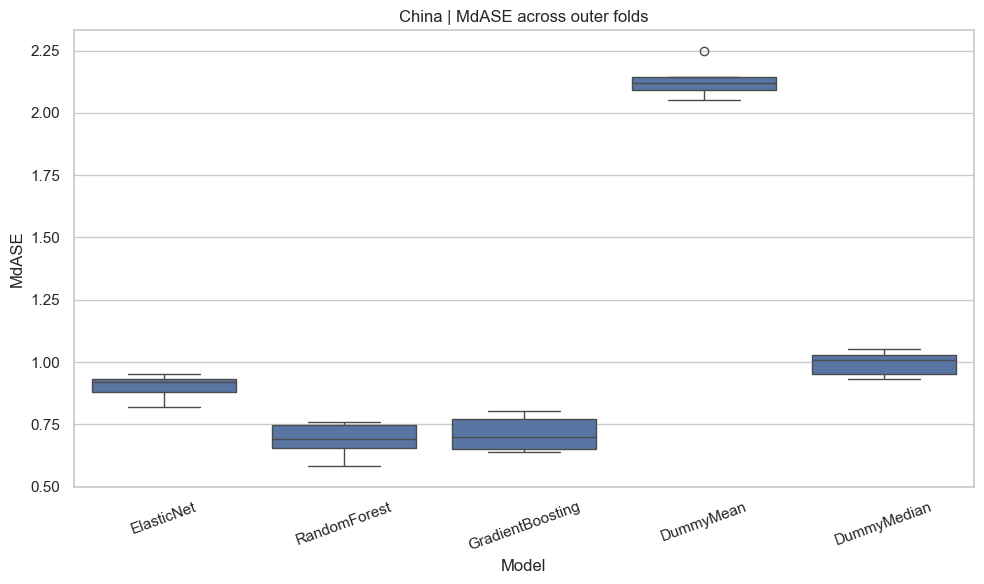

In [29]:
for dataset_name in results_df["dataset"].unique():
    dataset_results = results_df[results_df["dataset"] == dataset_name]

    for metric in metric_cols:
        plt.figure(figsize=(10, 6))
        ax = sns.boxplot(data=dataset_results, x="model", y=metric, order=MODEL_ORDER)
        ax.set_title(f"{dataset_name} | {metric} across outer folds")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"boxplot_{dataset_name.lower()}_{metric.lower()}.png", dpi=150)
        plt.show()


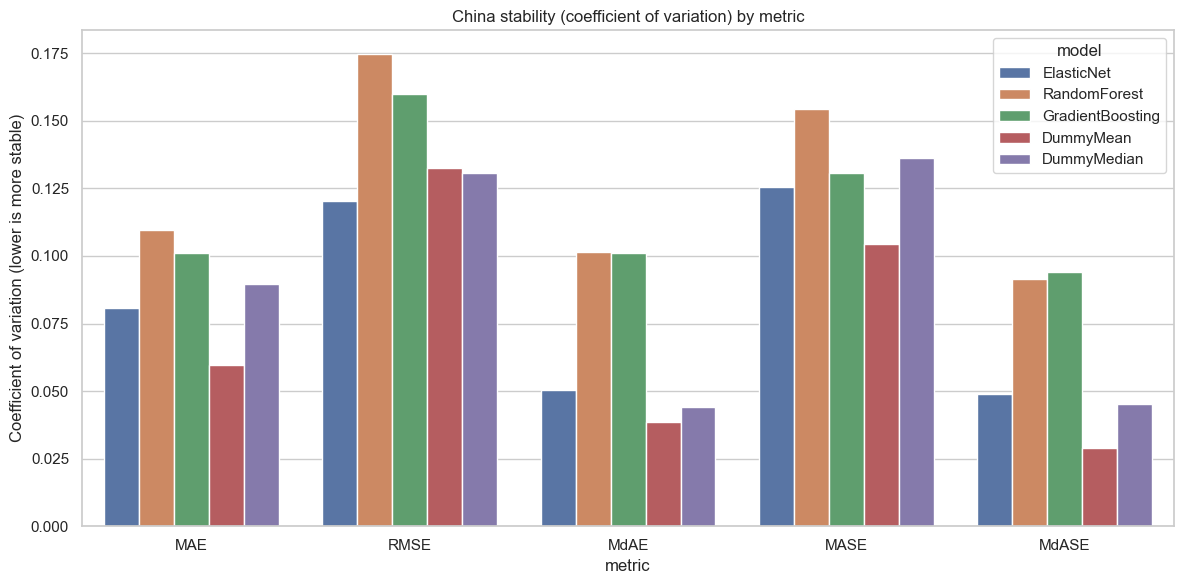

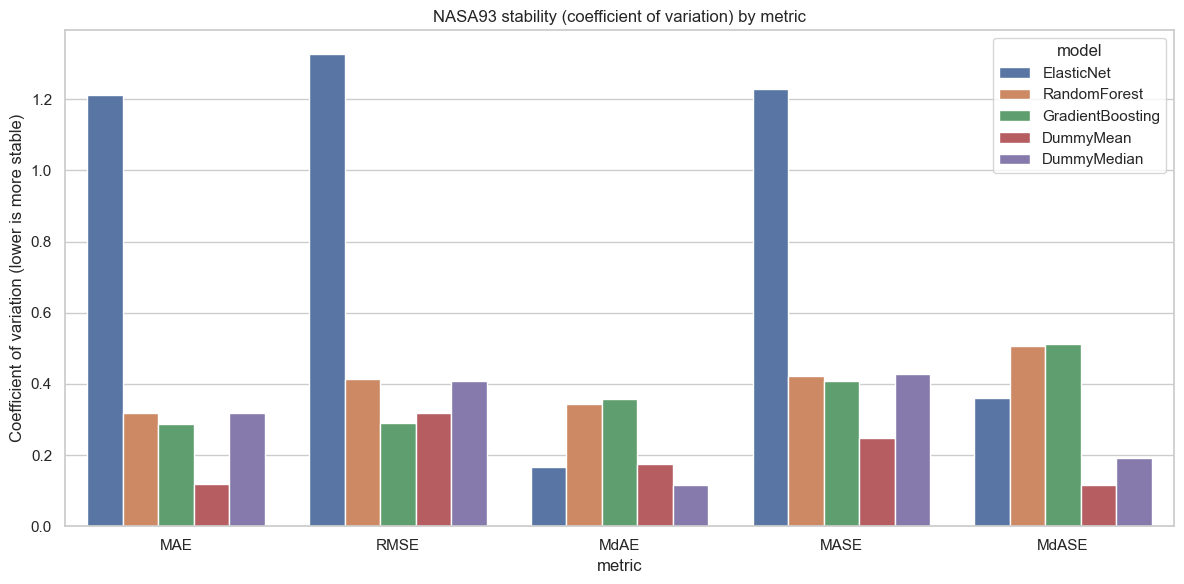

In [30]:
stability_rows = []
for (dataset_name, model_name), g in results_df.groupby(["dataset", "model"]):
    for metric in metric_cols:
        m = g[metric].mean()
        s = g[metric].std(ddof=0)
        cv = s / (m + EPSILON)
        stability_rows.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                "metric": metric,
                "mean": m,
                "std": s,
                "coef_var": cv,
            }
        )

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(BASE_DIR / "stability_metrics.csv", index=False)

for dataset_name in stability_df["dataset"].unique():
    dataset_stability = stability_df[stability_df["dataset"] == dataset_name]
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=dataset_stability, x="metric", y="coef_var", hue="model", hue_order=MODEL_ORDER)
    ax.set_title(f"{dataset_name} stability (coefficient of variation) by metric")
    ax.set_ylabel("Coefficient of variation (lower is more stable)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"stability_coefvar_{dataset_name.lower()}.png", dpi=150)
    plt.show()


## 10. Report Support Outputs

The cells below export compact markdown tables that can be copied directly into the technical report draft.


In [31]:
summary_for_report = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .mean()
    .round(4)
    .sort_values(["dataset", "MAE", "RMSE"])
)

markdown_table = summary_for_report.to_markdown(index=False)
print(markdown_table)

with open(BASE_DIR / "summary_table.md", "w", encoding="utf-8") as f:
    f.write(markdown_table + "\n")

print("Saved summary markdown table to summary_table.md")



| dataset   | model            |      MAE |      RMSE |      MdAE |   MASE |   MdASE |
|:----------|:-----------------|---------:|----------:|----------:|-------:|--------:|
| China     | RandomForest     | 2332.23  |  4937.14  |  907.178  | 0.7551 |  0.6889 |
| China     | GradientBoosting | 2401.9   |  5272.8   |  937.92   | 0.7758 |  0.7125 |
| China     | ElasticNet       | 2967.71  |  6331.7   | 1186.5    | 0.9597 |  0.9018 |
| China     | DummyMedian      | 3111.96  |  6738.01  | 1309.25   | 1.007  |  0.9952 |
| China     | DummyMean        | 3695.85  |  6425.17  | 2801.23   | 1.194  |  2.1286 |
| NASA93    | GradientBoosting |  341.288 |   753.174 |   80.3713 | 0.6845 |  0.43   |
| NASA93    | RandomForest     |  363.754 |   837.213 |  105.647  | 0.7316 |  0.5536 |
| NASA93    | DummyMedian      |  546.446 |  1105.36  |  223.2    | 1.1034 |  1.1036 |
| NASA93    | DummyMean        |  660.673 |  1095.78  |  501.226  | 1.2921 |  2.4232 |
| NASA93    | ElasticNet       | 3454.1   |

## 11. Interpretation Checklist

Use this section to complete the final narrative after execution:
- Which model has the lowest average MAE/RMSE per dataset?
- Do the tuned models beat `DummyMean` and `DummyMedian` consistently?
- Is ranking consistent across MAE, MdAE, MASE, and MdASE?
- Which model has lower fold variance once stability is separated by dataset?
- Do NASA93 and China favor the same model family after removing China leakage columns?
- How do skewness, sample size, and feature structure explain observed behavior?


## 12. References

- NASA93 dataset (PROMISE/Zenodo): https://zenodo.org/records/268419
- China dataset (PROMISE/Zenodo): https://zenodo.org/records/268446
- COC81 DEM fallback candidate (PROMISE/Zenodo): https://zenodo.org/records/268424
- Assignment metrics guidance: MAE, RMSE, MdAE, MASE, MdASE
